In [13]:
!git clone https://github.com/AmirMiraki/X-CGNN.git

Cloning into 'X-CGNN'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 52 (delta 17), reused 37 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 5.96 MiB | 10.70 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [15]:
!cp ./X-CGNN/util.py ./util.py
!cp ./X-CGNN/layer.py ./layer.py
!cp ./X-CGNN/net.py ./net.py
!cp ./X-CGNN/trainer.py ./trainer.py

In [5]:
import torch
torch.__version__

'2.6.0+cu124'

In [6]:
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv torch_geometric -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 47.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 104.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 85.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 73.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.8 MB/s eta 0:00:00


In [16]:
import argparse
import math
import time

import torch
import torch.nn as nn
from net import gtnet
import numpy as np
import importlib

from util import *
from trainer import Optim

parser = argparse.ArgumentParser(description='PyTorch Time series forecasting')
parser.add_argument('--data', type=str, default='/content/X-CGNN/Data/Tetuan/Tetuan_data.csv',
                    help='location of the data file')
parser.add_argument('--log_interval', type=int, default=100, metavar='N',
                    help='report interval')
parser.add_argument('--save', type=str, default='',
                    help='path to save the final model')
parser.add_argument('--optim', type=str, default='adam')
parser.add_argument('--L1Loss', type=bool, default=True)
parser.add_argument('--normalize', type=int, default=2)
parser.add_argument('--device',type=str,default='cuda:0',help='')
parser.add_argument('--gcn_true', type=bool, default=True, help='whether to add graph convolution layer')
parser.add_argument('--buildA_true', type=bool, default=True, help='whether to construct adaptive adjacency matrix')
parser.add_argument('--gcn_depth',type=int,default=2,help='graph convolution depth')
parser.add_argument('--num_nodes',type=int,default=8,help='number of nodes/variables')
parser.add_argument('--dropout',type=float,default=0.3,help='dropout rate')
parser.add_argument('--subgraph_size',type=int,default=8,help='k')
parser.add_argument('--node_dim',type=int,default=40,help='dim of nodes')
parser.add_argument('--dilation_exponential',type=int,default=2,help='dilation exponential')
parser.add_argument('--conv_channels',type=int,default=16,help='convolution channels')
parser.add_argument('--residual_channels',type=int,default=16,help='residual channels')
parser.add_argument('--skip_channels',type=int,default=32,help='skip channels')
parser.add_argument('--end_channels',type=int,default=64,help='end channels')
parser.add_argument('--in_dim',type=int,default=1,help='inputs dimension')
parser.add_argument('--seq_in_len',type=int,default=18,help='input sequence length')
parser.add_argument('--seq_out_len',type=int,default=1,help='output sequence length')
parser.add_argument('--horizon', type=int, default=6)
parser.add_argument('--layers',type=int,default=5,help='number of layers')

parser.add_argument('--batch_size',type=int,default=64,help='batch size')
parser.add_argument('--lr',type=float,default=0.0001,help='learning rate')
parser.add_argument('--weight_decay',type=float,default=0.00001,help='weight decay rate')

parser.add_argument('--clip',type=int,default=5,help='clip')

parser.add_argument('--propalpha',type=float,default=0.05,help='prop alpha')
parser.add_argument('--tanhalpha',type=float,default=3,help='tanh alpha')

parser.add_argument('--epochs',type=int,default=30,help='')
parser.add_argument('--num_split',type=int,default=1,help='number of splits for graphs')
parser.add_argument('--step_size',type=int,default=100,help='step_size')

parser.add_argument('-f')

args = parser.parse_args()
device = torch.device(args.device)
torch.set_num_threads(3)

Data = DataLoaderS(args.data, 0.6, 0.2, device, args.horizon, args.seq_in_len, args.normalize)


In [ ]:
import torch
import numpy as np
data_path='/content/X-CGNN/Data/Tetuan/Tetuan_data.csv'
data2=np.loadtxt(data_path,delimiter=',')
ntnl_model = torch.load('/content/X-CGNN/models/Tetuan_XCGNN_6.pt',weights_only=False)
ntnl_model.eval()

In [ ]:
X,y=next(Data.get_batches(Data.train[0], Data.train[1], 64, True))
scale = Data.scale.expand(X.size(0), Data.m)

In [ ]:
print(X.shape,y.shape)

torch.Size([64, 18, 8]) torch.Size([64, 8])


# single time and single feature

# single time and all feature

In [22]:
!pip install captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 113.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 821.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
from captum.attr import LayerConductance, LayerActivation, LayerIntegratedGradients, Lime, ShapleyValueSampling, IntegratedGradients
from captum.attr import IntegratedGradients, DeepLift, DeepLiftShap, GradientShap, NoiseTunnel, FeatureAblation, KernelShap

In [ ]:
def evalu(X):
  input = torch.unsqueeze(X,dim=1)
  input = input.transpose(2,3)
  outs=ntnl_model(input)
  outs = outs.squeeze()
  mae=torch.abs(outs[:,-3:]*scale[:,-3:]-y[:,-3:]*scale[:,-3:]).cpu().detach().numpy().mean()
  return mae


In [ ]:
ks = ShapleyValueSampling(ntnl_model)
input = torch.unsqueeze(X,dim=1)
input = input.transpose(2,3)
ks_attr_test=[]
# ks_attr_test=(ks.attribute(X_test))
for i in range(8):
  ks_attr_test.append(ks.attribute(input,target=(0,i)))
ks_attr_test_sum = ks_attr_test[0].cpu().detach().numpy().mean(0)
for i in range(7):
  ks_attr_test_sum += ks_attr_test[i+1].cpu().detach().numpy().mean(0)


In [ ]:
ks=abs(ks_attr_test_sum.reshape(-1))
ks2=abs(ks_attr_test_sum.transpose(0,2,1))
ks2=ks2.squeeze()
ks.sort()
ind=([int(len(ks)*(i)/100) for i in range(0,101,10)])
ind[0]=1
print(ind)

[1, 14, 28, 43, 57, 72, 86, 100, 115, 129, 144]


In [ ]:
shap_c=[]
for i in ind:#range(1,len(ks)+1):
  mask=np.where(ks2>ks[-i],1,0)
  masked_x=torch.mul(torch.tensor(mask).to(device),X)
  shap_c.append(evalu(masked_x))

In [ ]:
ks = DeepLift(ntnl_model)
input = torch.unsqueeze(X,dim=1)
input = input.transpose(2,3)
ks_attr_test=[]
# ks_attr_test=(ks.attribute(X_test))
for i in range(8):
  ks_attr_test.append(ks.attribute(input,target=(0,i)))
ks_attr_test_sum = ks_attr_test[0].cpu().detach().numpy().mean(0)
for i in range(7):
  ks_attr_test_sum += ks_attr_test[i+1].cpu().detach().numpy().mean(0)
ks=abs(ks_attr_test_sum.reshape(-1))
ks2=abs(ks_attr_test_sum.transpose(0,2,1))
ks2=ks2.squeeze()
ks.sort()
dl_c=[]
for i in ind:#range(1,len(ks)+1):
  mask=np.where(ks2>ks[-i],1,0)
  masked_x=torch.mul(torch.tensor(mask).to(device),X)
  dl_c.append(evalu(masked_x))

/usr/local/lib/python3.10/dist-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(


In [ ]:
ks = Lime(ntnl_model)
input = torch.unsqueeze(X,dim=1)
input = input.transpose(2,3)
ks_attr_test=[]
# ks_attr_test=(ks.attribute(X_test))
for i in range(8):
  ks_attr_test.append(ks.attribute(input,target=(0,i)))
ks_attr_test_sum = ks_attr_test[0].cpu().detach().numpy().mean(0)
for i in range(7):
  ks_attr_test_sum += ks_attr_test[i+1].cpu().detach().numpy().mean(0)
ks=abs(ks_attr_test_sum.reshape(-1))
ks2=abs(ks_attr_test_sum.transpose(0,2,1))
ks2=ks2.squeeze()
ks.sort()
lime_c=[]
for i in ind:#range(1,len(ks)+1):
  mask=np.where(ks2>ks[-i],1,0)
  masked_x=torch.mul(torch.tensor(mask).to(device),X)
  lime_c.append(evalu(masked_x))

/usr/local/lib/python3.10/dist-packages/captum/attr/_core/lime.py:1115: UserWarning: You are providing multiple inputs for Lime / Kernel SHAP attributions. This trains a separate interpretable model for each example, which can be time consuming. It is recommended to compute attributions for one example at a time.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/captum/attr/_core/lime.py:1115: UserWarning: You are providing multiple inputs for Lime / Kernel SHAP attributions. This trains a separate interpretable model for each example, which can be time consuming. It is recommended to compute attributions for one example at a time.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/captum/attr/_core/lime.py:1115: UserWarning: You are providing multiple inputs for Lime / Kernel SHAP attributions. This trains a separate interpretable model for each example, which can be time consuming. It is recommended to compute attributions for one example at a time.
  warnings.warn(
/usr

In [ ]:
ks = IntegratedGradients(ntnl_model)
input = torch.unsqueeze(X,dim=1)
input = input.transpose(2,3)
ks_attr_test=[]
# ks_attr_test=(ks.attribute(X_test))
for i in range(8):
  ks_attr_test.append(ks.attribute(input,target=(0,i)))
ks_attr_test_sum = ks_attr_test[0].cpu().detach().numpy().mean(0)
for i in range(7):
  ks_attr_test_sum += ks_attr_test[i+1].cpu().detach().numpy().mean(0)
ks=abs(ks_attr_test_sum.reshape(-1))
ks2=abs(ks_attr_test_sum.transpose(0,2,1))
ks2=ks2.squeeze()
ks.sort()
ig_c=[]
for i in ind:#range(1,len(ks)+1):
  mask=np.where(ks2>ks[-i],1,0)
  masked_x=torch.mul(torch.tensor(mask).to(device),X)
  ig_c.append(evalu(masked_x))

In [ ]:
input = torch.unsqueeze(X,dim=1)
input = input.transpose(2,3)
fa = FeatureAblation(ntnl_model)
fa_attr_test = fa.attribute(input)
fa_attr_test_sum = fa_attr_test.cpu().detach().numpy().mean(0)

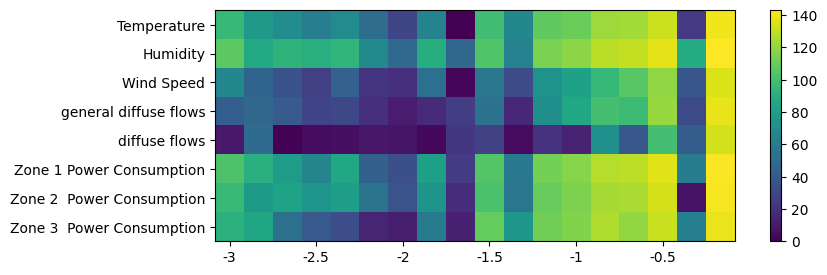

In [ ]:
feature_names =["Temperature","Humidity","Wind Speed","general diffuse flows","diffuse flows","Zone 1 Power Consumption","Zone 2  Power Consumption","Zone 3  Power Consumption"]
res=abs(fa_attr_test_sum[0,:,:])
order_res=np.zeros_like(res)
rr = res.copy().reshape(-1)
rr.sort()

for j in range(res.shape[0]):
  for k in range(res.shape[1]):
    for i in range(len(rr)):
      if res[j,k]==rr[i]:
        order_res[j,k]=i
        # print(j,k,i)
        break

  # order_res=np.where(res==rr[i],i,order_res)

import matplotlib.pyplot as plt
plt.figure(figsize=(9,3))
plt.imshow(order_res[:,:])
plt.xticks([0,3,6,9,12,15],labels=["-3","-2.5","-2","-1.5","-1","-0.5"])
plt.yticks([0,1,2,3,4,5,6,7],labels=feature_names)
plt.colorbar()

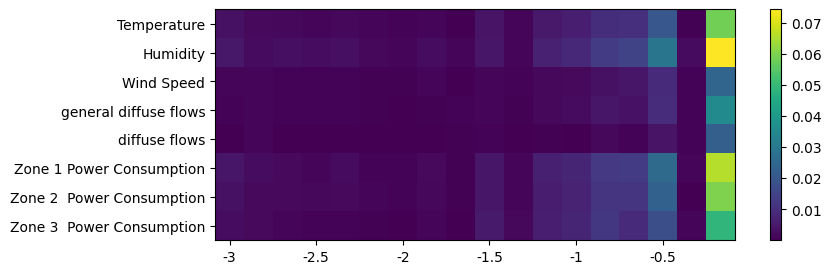

In [ ]:
plt.figure(figsize=(9,3))
plt.imshow(res[:,:])
plt.xticks([0,3,6,9,12,15],labels=["-3","-2.5","-2","-1.5","-1","-0.5"])
plt.yticks([0,1,2,3,4,5,6,7],labels=feature_names)
plt.colorbar()

In [ ]:
ks=abs(fa_attr_test_sum.reshape(-1))
ks2=abs(fa_attr_test_sum.transpose(0,2,1))
ks2=ks2.squeeze()
ks.sort()

In [ ]:
fa_c=[]
for i in ind:#range(1,len(ks)+1):
  mask=np.where(ks2>ks[-i],1,0)
  masked_x=torch.mul(torch.tensor(mask).to(device),X)
  fa_c.append(evalu(masked_x))

Text(0.5, 0, 'Selected Features')

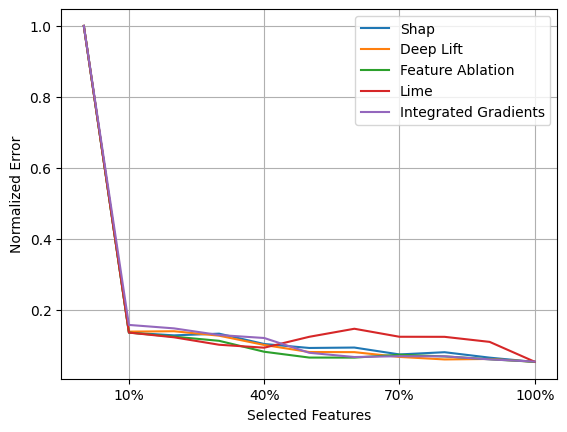

In [ ]:
# ind=([i*len(shap_c)//100 for i in range(0,100,9)])

plt.plot(shap_c/max(shap_c))
plt.plot(dl_c/max(dl_c))
plt.plot(fa_c/max(fa_c))
plt.plot(lime_c/max(lime_c))
plt.plot(ig_c/max(ig_c))
plt.legend(["Shap","Deep Lift","Feature Ablation","Lime","Integrated Gradients"])
plt.grid("on")
plt.xticks([1,4,7,10],labels=["10%","40%","70%","100%"])
plt.ylabel("Normalized Error")
plt.xlabel("Selected Features")
# print("Shap:",shap_c[-1]," FA:",fa_c[-1]," our:",our_c[-1])